In [45]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
import kagglehub
import os
from PIL import Image
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics  import classification_report , confusion_matrix , accuracy_score

## **Load Dataset**

In [3]:
path = kagglehub.dataset_download("fahimabrarsami/brain-tumor")
print(path)

100%|██████████| 157M/157M [00:20<00:00, 8.05MB/s] 

Extracting files...


C:\Users\INTEL\.cache\kagglehub\datasets\fahimabrarsami\brain-tumor\versions\1


In [7]:
print(os.listdir(path))

['Testing', 'Training']


In [8]:
train_path = os.path.join(path, "Training")
test_path = os.path.join(path, "Testing")

print(train_path)
print(test_path)

C:\Users\INTEL\.cache\kagglehub\datasets\fahimabrarsami\brain-tumor\versions\1\Training
C:\Users\INTEL\.cache\kagglehub\datasets\fahimabrarsami\brain-tumor\versions\1\Testing


In [10]:
train_path = os.path.join(path, "Training")
test_path = os.path.join(path, "Testing")

print("Training:")
print(os.listdir(train_path))

print("\nTesting:")
print(os.listdir(test_path))

Training:
['glioma', 'meningioma', 'notumor', 'pituitary']

Testing:
['glioma', 'meningioma', 'notumor', 'pituitary']


In [11]:
for cls in os.listdir(train_path):
    train_count = len(os.listdir(os.path.join(train_path, cls)))
    test_count = len(os.listdir(os.path.join(test_path, cls)))

    print(f"{cls}:")
    print(f"  Training: {train_count}")
    print(f"  Testing : {test_count}")
    print()

glioma:
  Training: 1400
  Testing : 400

meningioma:
  Training: 1400
  Testing : 400

notumor:
  Training: 1400
  Testing : 400

pituitary:
  Training: 1400
  Testing : 400



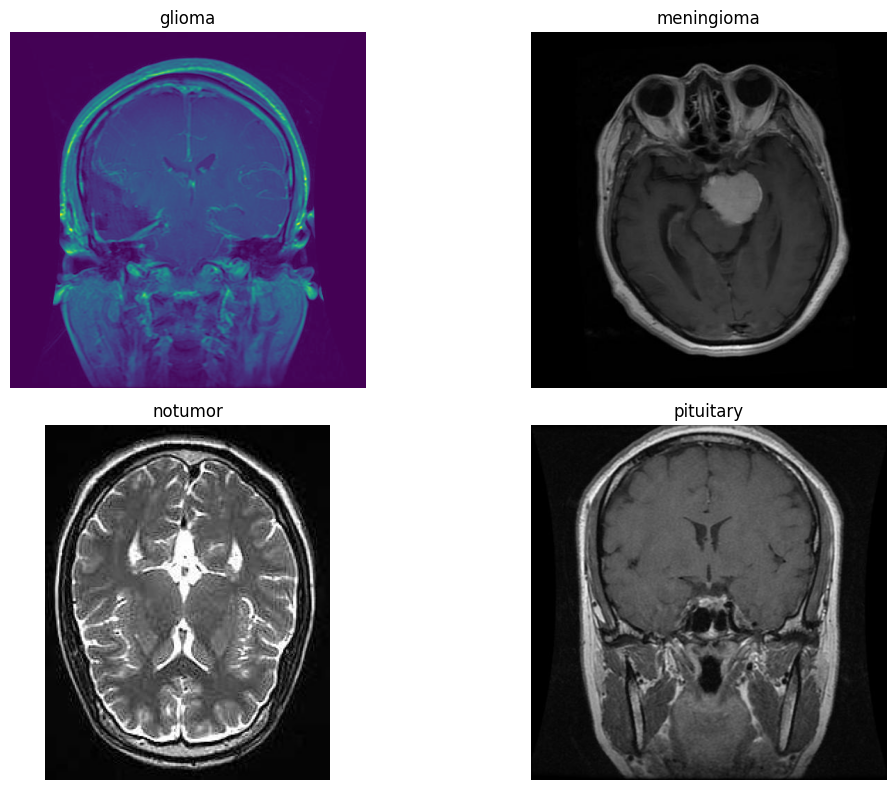

In [14]:
classes = os.listdir(train_path)

plt.figure(figsize=(12, 8))

for i, cls in enumerate(classes):
    folder = os.path.join(train_path, cls)
    
    image_name = os.listdir(folder)[0]
    image_path = os.path.join(folder, image_name)
    
    image = Image.open(image_path)

    plt.subplot(2, 2, i + 1)
    plt.imshow(image)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
for cls in classes:
    folder = os.path.join(train_path, cls)
    
    image_name = os.listdir(folder)[0]
    image_path = os.path.join(folder, image_name)
    
    image = Image.open(image_path)
    
    print(f"{cls}: {image.size}")

glioma: (512, 512)
meningioma: (512, 512)
notumor: (201, 251)
pituitary: (512, 512)


In [17]:
image_name = os.listdir(os.path.join(train_path, classes[0]))[0]
image_path = os.path.join(train_path, classes[0], image_name)

# Image load
image = Image.open(image_path).convert("RGB")

print("Original size:", image.size)

# Resize
image = image.resize((224, 224))

# Convert to NumPy array
image_array = np.array(image)

# Normalize
image_array = image_array / 255.0

print("After resize:", image_array.shape)
print("Minimum pixel value:", image_array.min())
print("Maximum pixel value:", image_array.max())

Original size: (512, 512)
After resize: (224, 224, 3)
Minimum pixel value: 0.0
Maximum pixel value: 0.9529411764705882


In [ ]:


IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=42
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=42
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Classes:", train_dataset.class_names)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
Found 1600 files belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


Normalization + Augmentation

In [ ]:
# Normalize pixel values: 0-255 → 0-1
normalization_layer = layers.Rescaling(1./255)

# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

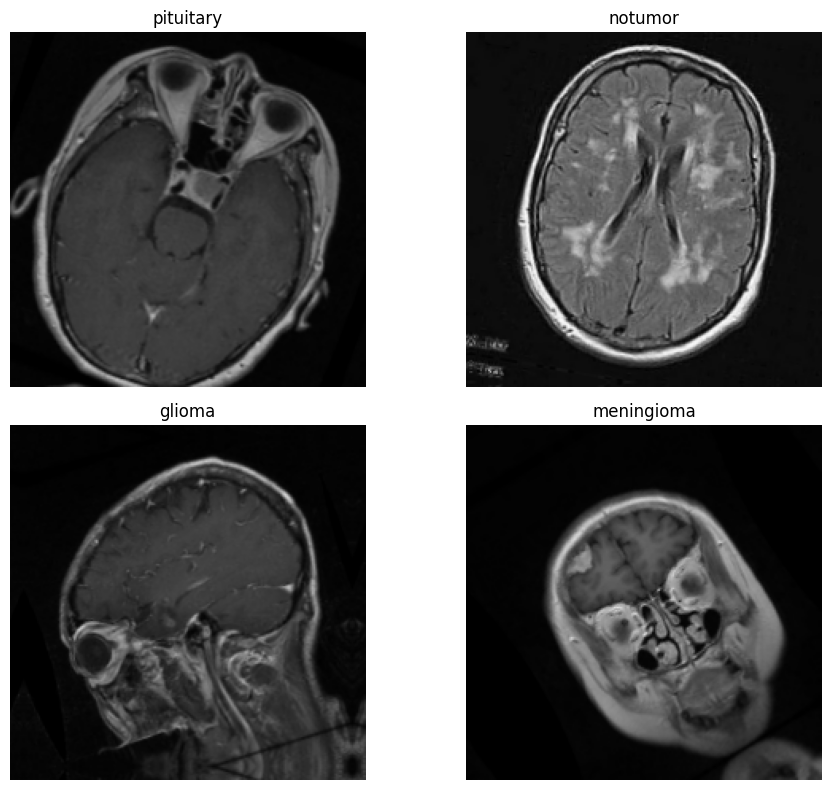

In [24]:
# Training dataset batch 1
images, labels = next(iter(train_dataset))

# first 4 images
plt.figure(figsize=(10, 8))

for i in range(4):
    augmented_image = data_augmentation(images[i])

    plt.subplot(2, 2, i + 1)
    plt.imshow(augmented_image.numpy().astype("uint8"))
    plt.title(train_dataset.class_names[labels[i]])
    plt.axis("off")

plt.tight_layout()

plt.show()

Final Data Pipeline

In [26]:
# Image size
IMG_SIZE = (224, 224)

# every batch contains 32 images
BATCH_SIZE = 32

# Training data
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=42
)

# Validation data
val_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=42
)

# Testing data
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training images: 4480")
print("Validation images: 1120")
print("Testing images: 1600")
print("Classes:", train_dataset.class_names)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
Found 1600 files belonging to 4 classes.
Training images: 4480
Validation images: 1120
Testing images: 1600
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [27]:
normalization = layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (normalization(x), y))

val_dataset = val_dataset.map(lambda x, y: (normalization(x), y))

test_dataset = test_dataset.map(lambda x, y: (normalization(x), y))

print("Normalization complete!")

Normalization complete!


## CNN Model

In [33]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, 3, activation='relu', input_shape=(224, 224, 3)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(4, activation='softmax')
])

model.summary()

c:\Users\INTEL\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model.compile(optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model is ready for training!")

Model is ready for training!


In [ ]:
history = model.fit(train_dataset,validation_data=val_dataset,epochs=10)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 87s 610ms/step - accuracy: 0.6362 - loss: 0.8977 - val_accuracy: 0.8170 - val_loss: 0.4869
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 580ms/step - accuracy: 0.8100 - loss: 0.4964 - val_accuracy: 0.8848 - val_loss: 0.3405
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 577ms/step - accuracy: 0.8623 - loss: 0.3579 - val_accuracy: 0.8804 - val_loss: 0.3000
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 575ms/step - accuracy: 0.8958 - loss: 0.2596 - val_accuracy: 0.9027 - val_loss: 0.2682
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 82s 581ms/step - accuracy: 0.9201 - loss: 0.2005 - val_accuracy: 0.9330 - val_loss: 0.2042
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 580ms/step - accuracy: 0.9279 - loss: 0.1789 - val_accuracy: 0.9321 - val_loss: 0.2131
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 576ms/step - accuracy: 0.9498 - loss: 0.1353 - val_accuracy: 0.9402 - val_loss: 0.1866
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 578ms/step - accuracy: 0.9585 - loss: 0

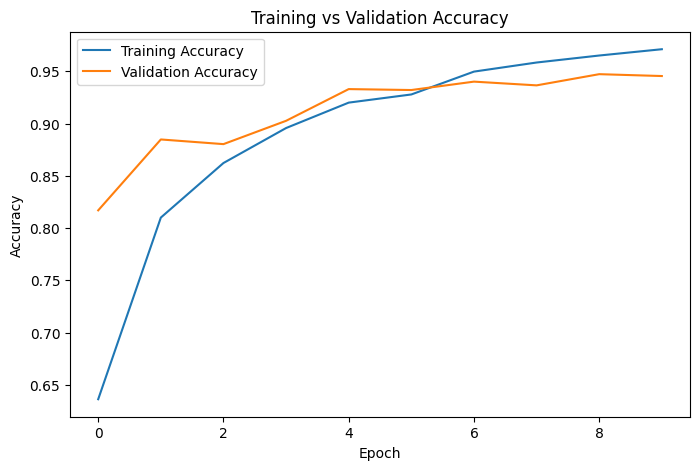

In [36]:
# Accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

In [37]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 157ms/step - accuracy: 0.8712 - loss: 1.2289
Test Accuracy: 0.8712499737739563
Test Loss: 1.2288786172866821


In [40]:
from sklearn.metrics import classification_report
import numpy as np

# Class names
class_names = ["glioma", "meningioma", "notumor", "pituitary"]

# Actual labels
y_true = []

for images, labels in test_dataset:
    y_true.extend(labels.numpy())

# Model prediction
predictions = model.predict(test_dataset)

# Get class number
y_pred = np.argmax(predictions, axis=1)

# Classification report
report = classification_report(
    y_true,
    y_pred,
    labels=[0, 1, 2, 3],
    target_names=class_names
)

print(report)

50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step
              precision    recall  f1-score   support

      glioma       0.88      0.76      0.81       400
  meningioma       0.85      0.82      0.84       400
     notumor       0.81      0.99      0.89       400
   pituitary       0.96      0.92      0.94       400

    accuracy                           0.87      1600
   macro avg       0.88      0.87      0.87      1600
weighted avg       0.88      0.87      0.87      1600



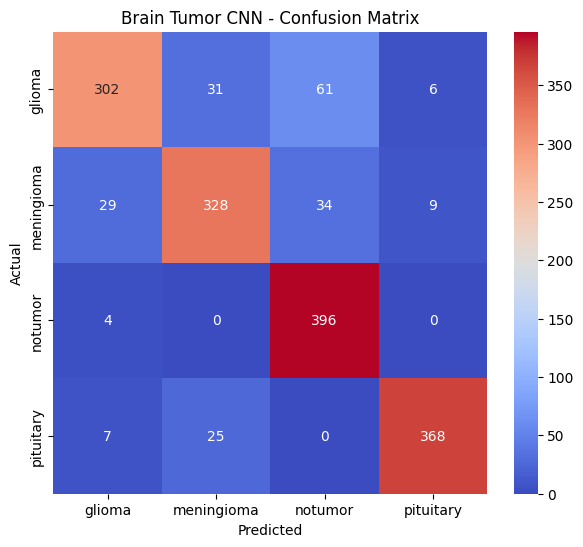

In [46]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))

sns.heatmap(cm,annot=True,fmt="d",xticklabels=class_names,yticklabels=class_names,cmap='coolwarm')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Brain Tumor CNN - Confusion Matrix")

plt.show()

In [47]:
import tensorflow as tf
from tensorflow.keras import layers, models

# MobileNetV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Pretrained layers freeze
base_model.trainable = False

print("MobileNetV2 loaded!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
MobileNetV2 loaded!
